# EDA for Loan Approval Dataset

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./loan_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [70]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [71]:
df.columns = ['Age', 'Sex', 'Education', 'Income', 'Employment Exp', 'Ownership', 'Loan Amt', 'Loan Intent', 'Loan Interest Rate', 'Loan percent income', 'Credit History Length', 'Credit Score', 'Previous Loan Defaults', 'Loan Status']
df.head()

,Age,Sex,Education,Income,Employment Exp,Ownership,Loan Amt,Loan Intent,Loan Interest Rate,Loan percent income,Credit History Length,Credit Score,Previous Loan Defaults,Loan Status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [72]:
df = df[(df['Age'] <= 100) & (df['Employment Exp'] <= 100)]

In [73]:
string_columns = df.select_dtypes(include='string')
for col in string_columns.columns:
    print(f"{col} : {df[col].value_counts()}\n")

Sex : Sex
male      24836
female    20157
Name: count, dtype: int64

Education : Education
Bachelor       13396
Associate      12026
High School    11970
Master          6980
Doctorate        621
Name: count, dtype: int64

Ownership : Ownership
RENT        23440
MORTGAGE    18485
OWN          2951
OTHER         117
Name: count, dtype: int64

Loan Intent : Loan Intent
EDUCATION            9151
MEDICAL              8548
VENTURE              7815
PERSONAL             7551
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

Previous Loan Defaults : Previous Loan Defaults
Yes    22856
No     22137
Name: count, dtype: int64



In [76]:
df.describe()

,Age,Income,Employment Exp,Loan Amt,Loan Interest Rate,Loan percent income,Credit History Length,Credit Score,Loan Status
count,44993.000000,4.499300e+04,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000,44993.000000
mean,27.748428,7.990845e+04,5.394528,9583.176761,11.006448,0.139736,5.866557,632.585713,0.222257
std,5.909737,6.332213e+04,5.927159,6314.802655,2.978985,0.087207,3.877167,50.402411,0.415767
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719500e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577800e+04,8.000000,12237.000000,12.990000,0.190000,8.000000,670.000000,0.000000
max,94.000000,2.448661e+06,76.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


# Univariate Analysis

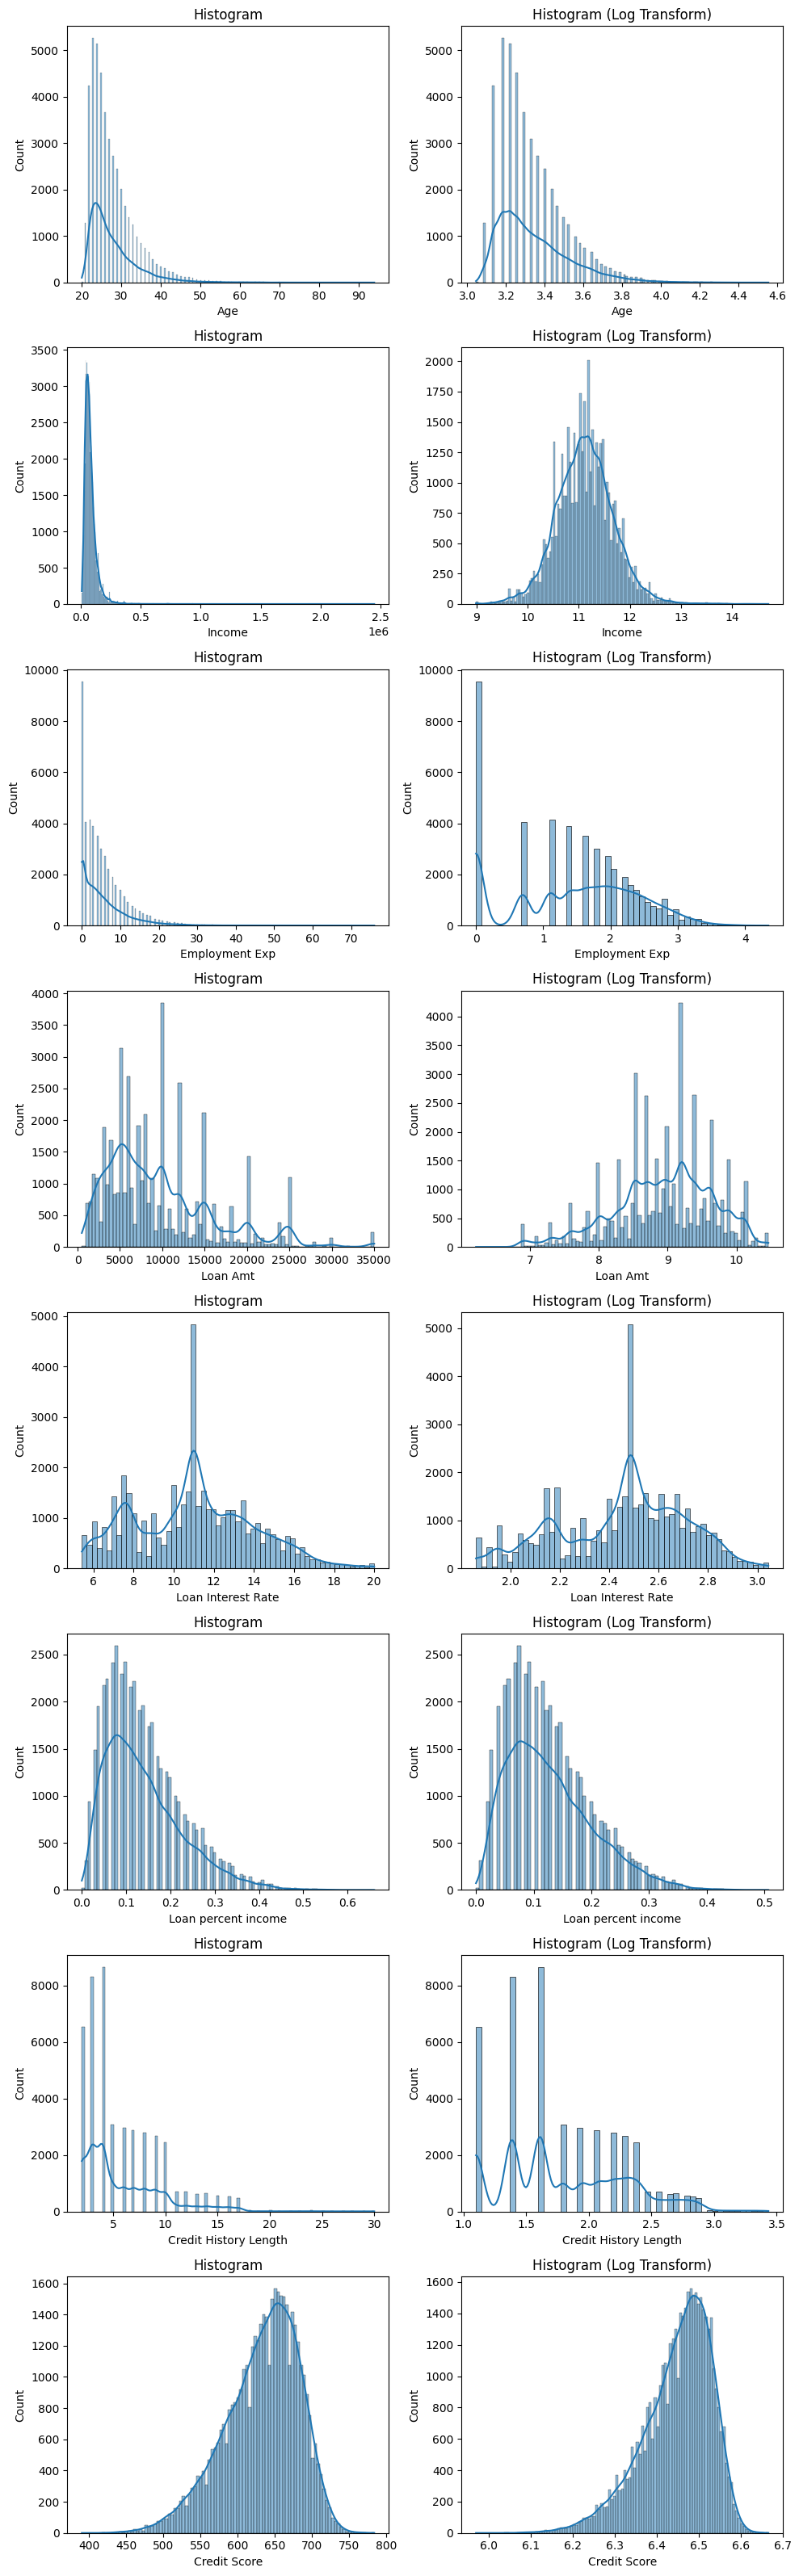

In [84]:
num_cols = df.select_dtypes("number").columns[:-1]
n = len(num_cols)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for index, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[index, 0])
    axes[index, 0].set_title(f"Histogram")

    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[index, 1])
    axes[index, 1].set_title(f"Histogram (Log Transform)")

plt.tight_layout()
plt.show()

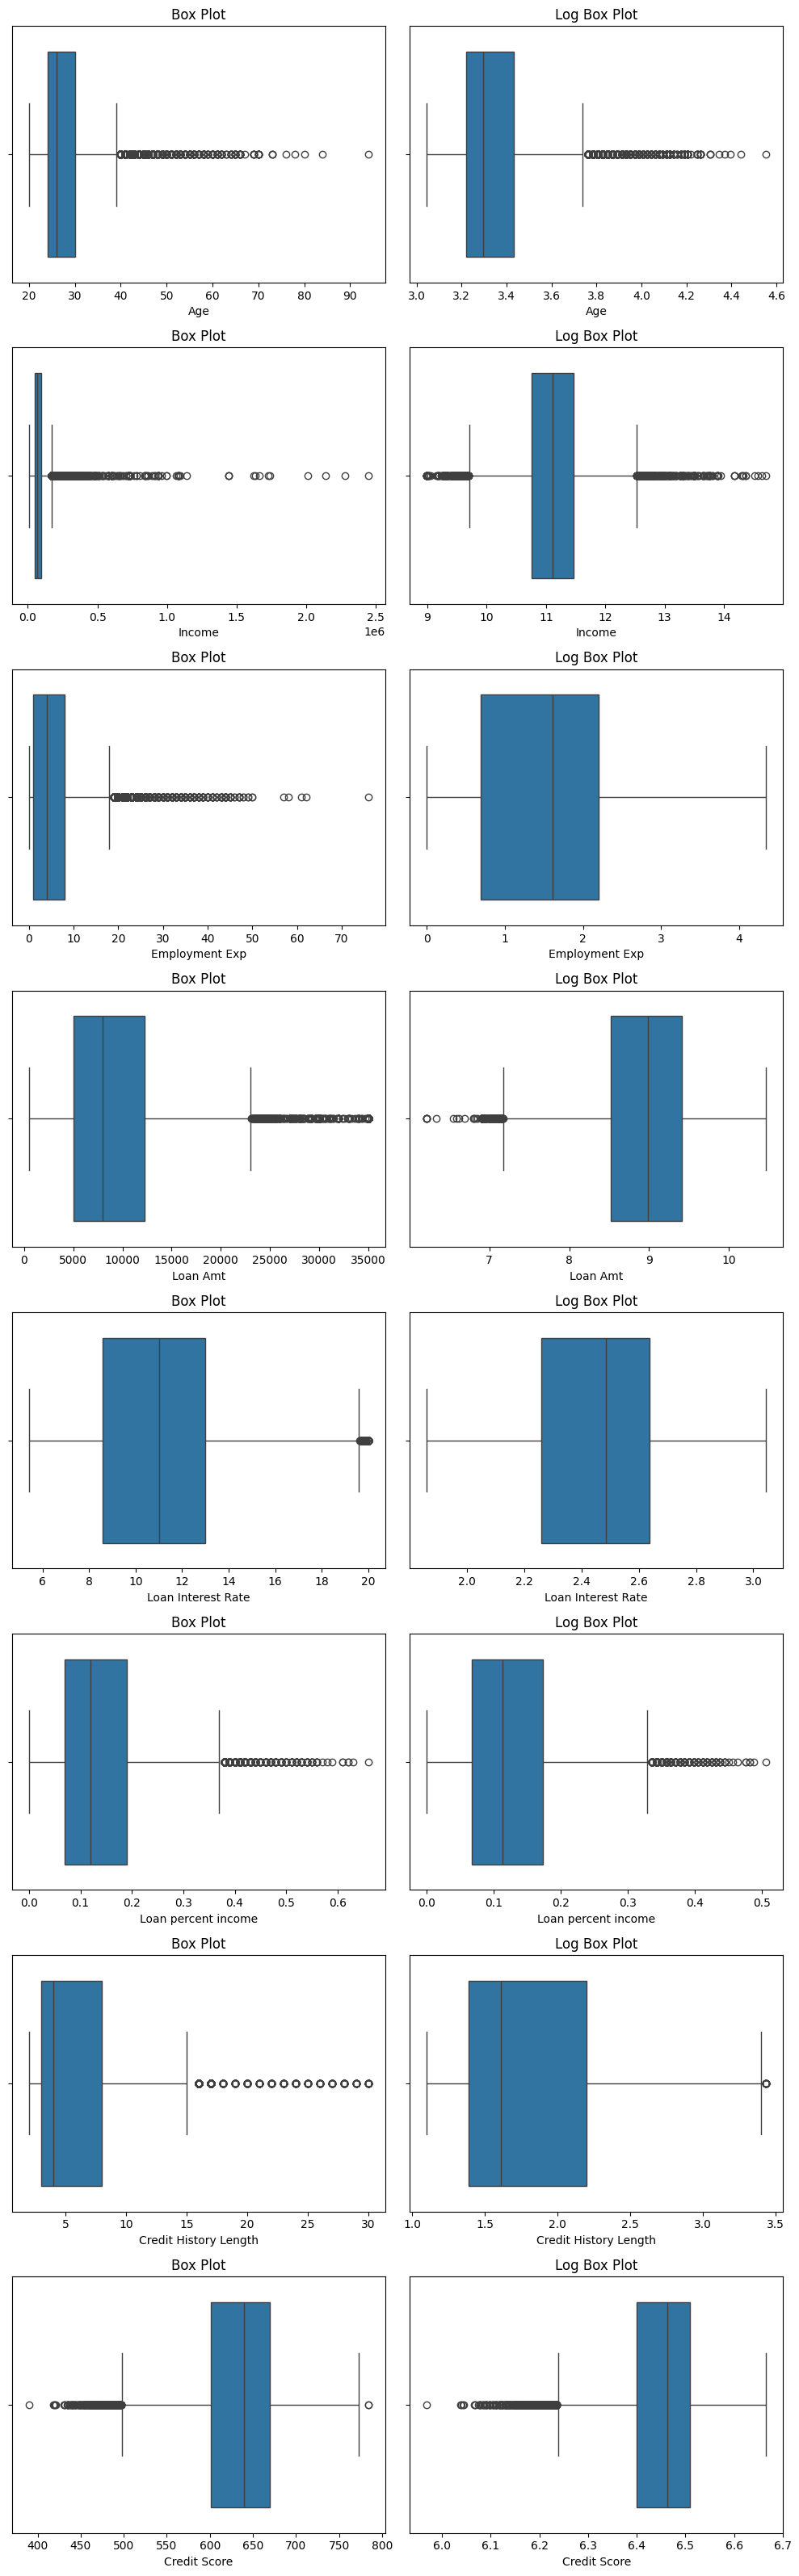

In [86]:
num_cols = df.select_dtypes("number").columns[:-1]
n = len(num_cols)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for index, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[index, 0])
    axes[index, 0].set_title(f"Box Plot")

    sns.boxplot(x=np.log1p(df[col]), ax=axes[index, 1])
    axes[index, 1].set_title(f"Log Box Plot")

plt.tight_layout()
plt.show()

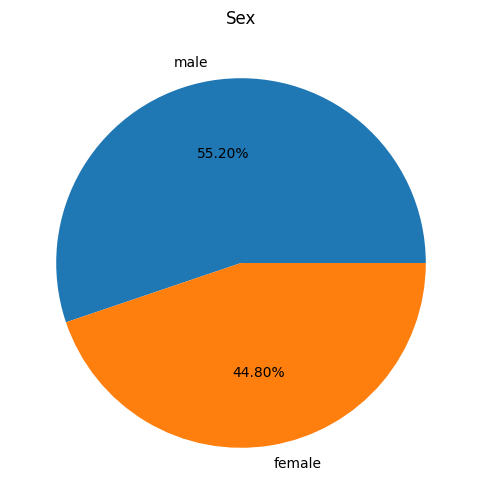

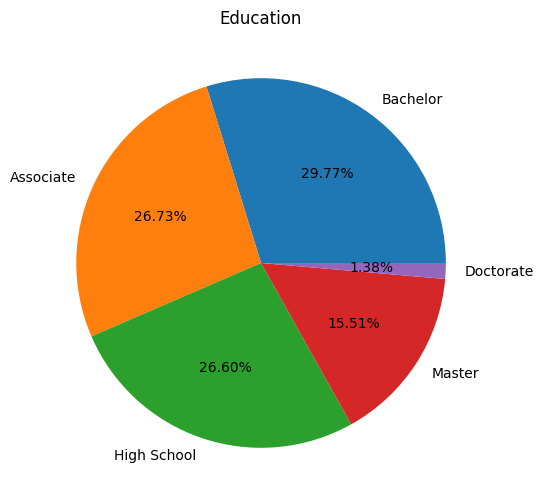

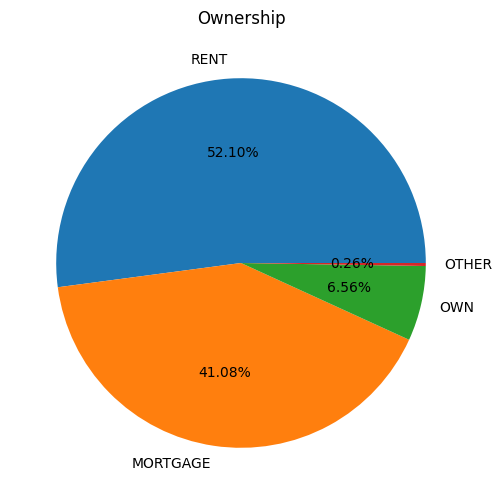

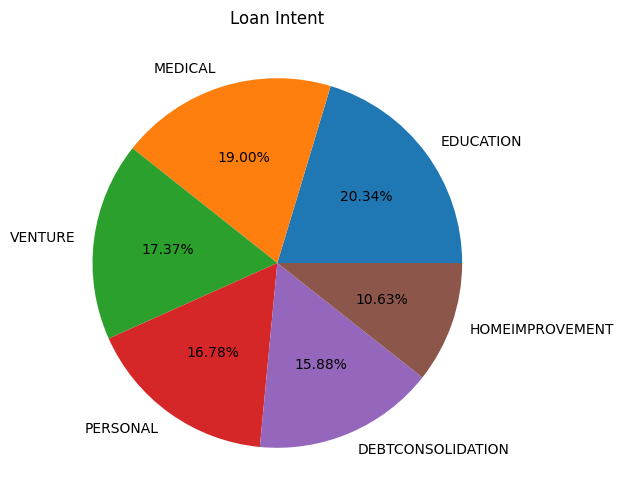

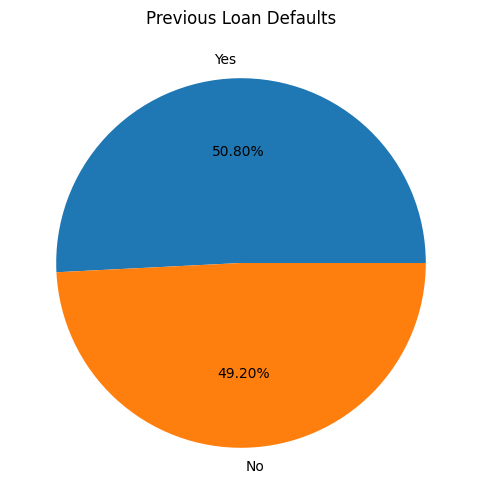

In [89]:
string_cols = string_columns.columns
for col in string_cols:
    plt.figure(figsize=(6,6))

    types = df[col].value_counts().index
    values = df[col].value_counts().values
    
    plt.pie(values, labels=types, autopct="%.2f%%")
    plt.title(col)
    plt.show()

# Observations of Univariate Analysis

From the histograms, we can observe that the log transformation helps in normalizing the **Income, Employment Exp, Loan Amt and Credit History Length** features

From the boxplots, we can observe similar results. Log boxplots have shown to reduce outliers for **Employment Exp, Loan Interest Rate, Credit History Length**

This shows that log transformations are helpful in normalizing the data and reducing the number of outliers

From the pie charts, we observe the following :
- **Sex, Loan Intent, Previous Loan Defaults** Classes are equally distributed
- **Education** class has an imbalance as Doctorates contribute to around 1% of the pie
- **Ownership** class also has an imbalance as the **OWN** and **OTHERS** together only contribute around 7% of the pie

These class imbalances may favour ML models into predicting based on the highly recurrent values.

# Bivariate Analysis

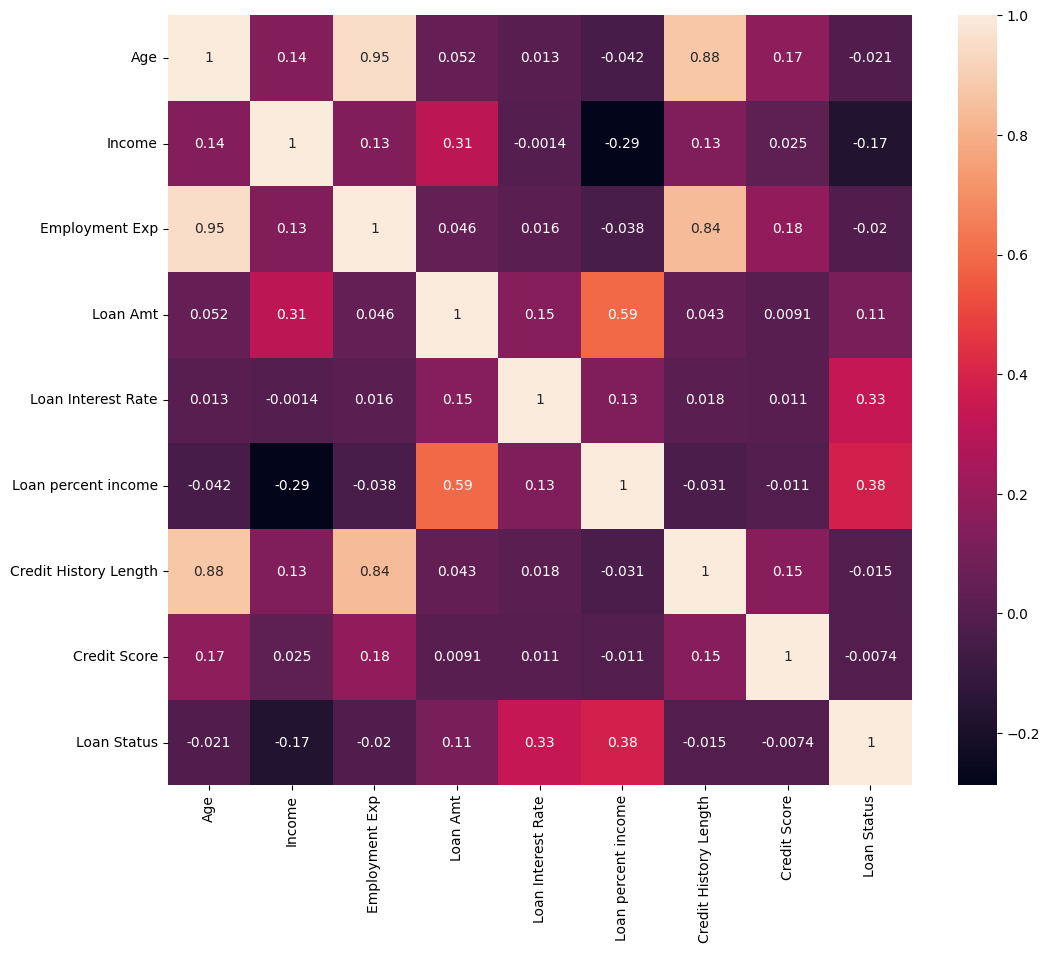

In [95]:
corr = df.select_dtypes(include=['int', 'float']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True)
plt.show()

# Observations of Bivariate Analysis

- **Income, Loan Interest Rate, Loan percent income** are strong predictors of Loan Status
- Multicollinearity exists in **Age v/s Employment Exp** and **Age v/s Credit History Length**

# Model Preparation Steps

Perform the following steps to build the classification model

- Apply log transformation for **Income, Employment Exp, Loan Amt, Credit History Length**
- Drop **Age** feature as multicollinearity exists in **Age v/s Employment Exp** and **Age v/s Credit History Length**
- One Hot Encode the Categorical data
- Apply Standard Scaling